# Predictive-Maintenance MAS — Step 0: the deterministic loop

**Where this sits.** This is *Step 0* of the SPEC build order: prove the four-tool
contract end-to-end **before** any LLM or OpenClaw is in play. The pattern we are
replicating (Farahani et al.) is *one LLM orchestrator calling deterministic
tools*. The orchestrator plans and interprets; the tools compute. This notebook
exercises the tools and the plan with **no LLM at all**, so that when the agent is
added in Step 2 the only new variable is the agent.

**The paradigm bridge.** NGAFID-MC is a long multivariate time series (~23 sensors,
3600+ steps/flight). The agentic loop wants *tabular* rows. We bridge by collapsing
each flight to per-channel summary statistics (bridge 1). This deliberately discards
the temporally-distant structure Conv-MHSA exploits, so the AUC here is a **baseline,
not the headline** — the Conv-MHSA model swaps in behind the same `classify` tool later.

**What this notebook validates**
1. The tool contract: `inspect → featurize → classify → recommend` runs and the shapes line up.
2. The leakage guard: tail-disjoint (GroupKFold) validation, and *why it matters* (a measured honest-vs-leaked AUC gap).
3. The HITL summary the orchestrator must produce, generated deterministically from tool JSON.
4. CLI parity: the same loop via shell calls — exactly what OpenClaw will drive.

**What it does NOT validate:** real-data accuracy. That is Step 1 (real NGAFID baseline)
and Step 5 (Conv-MHSA swap). Keep the AUC claim and the orchestration claim separate.

In [1]:
%matplotlib inline
import json, subprocess, sys, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

note_dir = Path().resolve()
root = note_dir.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

DATA_DIR = root / "data"

csv_intake = "NGAFID_MC_INTAKE.csv"
csv_rocker = "NGAFID_MC_ROCKER.csv"

from scripts import tools
from scripts.synthdata import make_synthetic, make_synthetic_realistic, SIGNAL_CHANNELS
from scripts.featurize import build_feature_table, channel_features
from scripts.train_baseline import train, cross_validate, feature_columns
from scripts.orchestrator_sim import run_pipeline

pd.set_option("display.max_columns", 12); pd.set_option("display.width", 120)
WORK = Path("../nb_work"); shutil.rmtree(WORK, ignore_errors=True); WORK.mkdir()
print("env ready · signal channels in synthetic data:", SIGNAL_CHANNELS)

env ready · signal channels in synthetic data: ('vibration', 'oil_temp', 'egt')


## Part A — Synthetic flights with a learnable signal

Step 0 runs before the Kaggle download, so we fabricate NGAFID-shaped flights
(per-second rows, one column per sensor) with a *known* maintenance signal:
"problematic" flights (label 1) get a slow upward drift plus extra variance on a
few channels. If the loop can recover that, the plumbing is sound.

In [2]:
flight_dir, meta_path = make_synthetic(WORK/"easy", n_planes=10, flights_per_plane=8, steps=600, seed=7)
md_easy = pd.read_csv(meta_path)
print("flights on disk:", len(list((flight_dir).glob('*.csv'))), "| metadata rows:", len(md_easy))
md_easy.head(3)

flights on disk: 80 | metadata rows: 80


,filename,label,plane_id,cluster
0,plane0_flight0.csv,0,P0,C37
1,plane0_flight1.csv,0,P0,C37
2,plane0_flight2.csv,0,P0,C37


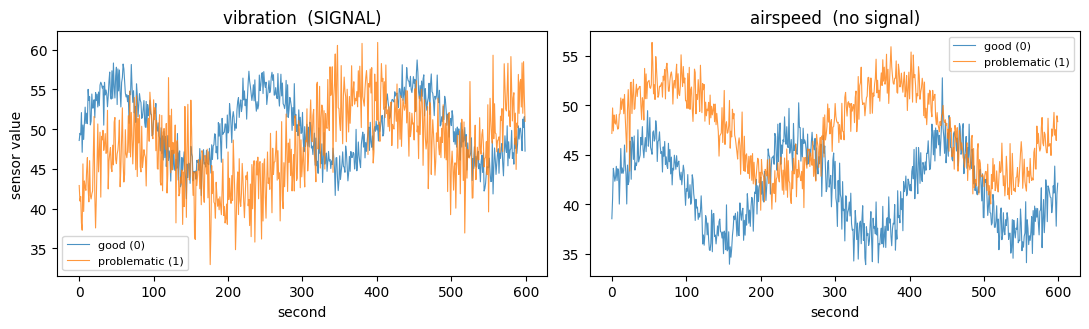

On a signal channel the problematic flight drifts upward; on a non-signal channel the two overlap.


In [3]:
# Visualise where the signal lives: a problematic vs a good flight,
# on a signal channel (vibration) and a non-signal channel (airspeed).
good = md_easy[md_easy.label==0].iloc[0]['filename']
bad  = md_easy[md_easy.label==1].iloc[0]['filename']
dfg = pd.read_csv(flight_dir/good); dfb = pd.read_csv(flight_dir/bad)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, ch in zip(ax, ['vibration', 'airspeed']):
    a.plot(dfg[ch].values, lw=.8, label='good (0)', alpha=.8)
    a.plot(dfb[ch].values, lw=.8, label='problematic (1)', alpha=.8)
    a.set_title(f"{ch}  ({'SIGNAL' if ch in SIGNAL_CHANNELS else 'no signal'})")
    a.set_xlabel("second"); a.legend(fontsize=8)
ax[0].set_ylabel("sensor value"); fig.tight_layout(); plt.show()
print("On a signal channel the problematic flight drifts upward; on a non-signal channel the two overlap.")

## Part B — The tool contract, one tool at a time

Four deterministic tools, each the seed of a future agent. None contains an LLM call.

| Tool | Future agent | I/O |
|---|---|---|
| `inspect_data` | Perception | dir+meta → inventory JSON |
| `featurize_flights` | Perception/Preproc | dir+meta → feature table |
| `classify_flights` | Analysis | feats+model → ranked preds |
| `recommend_maintenance` | Optimization | preds → write-only queue |

### Tool 1 · `inspect_data` — read-only sanity check
Flags class balance and channel inventory so the planner can sanity-check inputs
before spending compute. It reads a few flights, nothing more.

In [4]:
r_inspect = tools.inspect_data(str(flight_dir), str(meta_path))
print(json.dumps(r_inspect, indent=2))

{
  "tool": "inspect_data",
  "n_flights": 80,
  "label_balance": {
    "0": 46,
    "1": 34
  },
  "n_planes": 10,
  "detected_channels": [
    "engine_rpm",
    "oil_temp",
    "oil_pressure",
    "cht",
    "egt",
    "fuel_flow",
    "vibration",
    "airspeed",
    "altitude"
  ],
  "n_channels": 9,
  "example_flight_steps": 600,
  "notes": "Read-only. Flags class balance and channel inventory for the planner."
}


### Tool 2 · `featurize_flights` — MTS → tabular
Each flight collapses to a fixed-width row: **12 summary stats per channel**
(`mean, std, min, max, range, p10, p50, p90, slope, mean_abs_diff, max_abs_diff, last`)
plus `__n_steps`. `slope` and `p90`/`range` on the signal channels are where the
drift becomes visible to a tabular model.

In [5]:
table = build_feature_table(flight_dir, md_easy)
table.to_csv(WORK/"feats_easy.csv", index=False)
print("feature table:", table.shape, "→", table.shape[1]-3, "features + label/group/filename")
# the 12 stats for one signal channel, on the same good/bad flights from Part A
demo = pd.DataFrame({
    'good':        channel_features(dfg['vibration'].values),
    'problematic': channel_features(dfb['vibration'].values),
}).round(2)
print("\nvibration channel features (good vs problematic):")
demo

feature table: (80, 112) → 109 features + label/group/filename

vibration channel features (good vs problematic):


,good,problematic
mean,50.32,47.93
std,3.94,5.10
min,41.24,32.95
max,58.71,60.91
range,17.47,27.96
p10,45.18,41.29
p50,50.36,47.73
p90,55.55,54.59
slope,-0.00,0.01
mean_abs_diff,1.78,3.88


In [6]:
table[['filename','group','label'] + [c for c in table.columns if c.startswith('vibration__')][:4]].head(5)

,filename,group,label,vibration__mean,vibration__std,vibration__min,vibration__max
0,plane0_flight0.csv,P0,0,50.318397,3.940797,41.240748,58.708431
1,plane0_flight1.csv,P0,0,46.085431,3.777021,36.800093,55.269984
2,plane0_flight2.csv,P0,0,43.011585,3.776117,34.176646,51.703774
3,plane0_flight3.csv,P0,0,49.904311,3.894288,40.920439,58.082033
4,plane0_flight4.csv,P0,0,53.120315,3.844217,42.255825,61.268003


### Train the baseline · tail-disjoint cross-validation
The classifier is trained offline (this is `train_baseline.py`). The **non-negotiable**
detail: validation flights must come from tail numbers (`group`) absent from training,
or a model can memorise a plane's quirks and inflate AUC. `cross_validate` enforces this
with `GroupKFold` on `group`. (On this easy synthetic signal the AUC is near-perfect by
design — Part C is where we make it realistic and stress the split.)

In [7]:
metrics = train(table, WORK/"model_easy.joblib", WORK/"metrics_easy.json")
print(json.dumps(metrics, indent=2))

{
  "n_splits_used": 5,
  "roc_auc_mean": 1.0,
  "roc_auc_std": 0.0,
  "pr_auc_mean": 1.0,
  "accuracy_mean": 1.0,
  "n_features": 109,
  "n_flights": 80,
  "n_planes": 10,
  "class_balance": {
    "0": 46,
    "1": 34
  },
  "model_path": "../nb_work/model_easy.joblib"
}


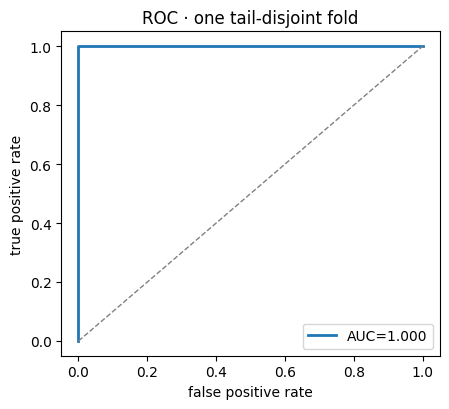

In [8]:
# ROC on a single tail-disjoint fold, for a visual
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_curve, roc_auc_score
cols = feature_columns(table)
X, y, g = table[cols].values, table['label'].values.astype(int), table['group'].values
tr, te = next(GroupKFold(5).split(X, y, g))
clf = HistGradientBoostingClassifier(random_state=0).fit(X[tr], y[tr])
p = clf.predict_proba(X[te])[:, 1]
fpr, tpr, _ = roc_curve(y[te], p)
plt.figure(figsize=(4.6,4.2))
plt.plot(fpr, tpr, lw=2, label=f"AUC={roc_auc_score(y[te],p):.3f}")
plt.plot([0,1],[0,1],'--',color='gray',lw=1)
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC · one tail-disjoint fold"); plt.legend(); plt.tight_layout(); plt.show()

### Tool 3 · `classify_flights` — probability + urgency
Loads the saved model, scores every flight, maps probability to an urgency band
(`HIGH ≥ 0.66`, `MEDIUM ≥ 0.33`, else `LOW`), and ranks. The thresholds live in the
*tool*, not the prompt — the orchestrator reads the result, it does not threshold.

{
  "tool": "classify_flights",
  "n_scored": 80,
  "n_high": 34,
  "out": "../nb_work/preds_easy.json"
}


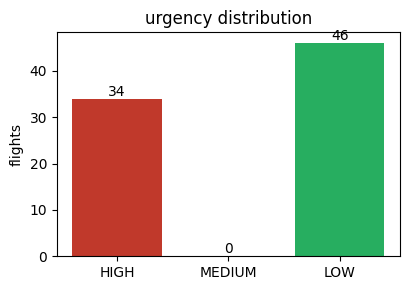

,flight,p_maintenance,urgency
0,plane0_flight5.csv,0.999972,HIGH
1,plane0_flight7.csv,0.999972,HIGH
2,plane1_flight1.csv,0.999972,HIGH
3,plane1_flight2.csv,0.999972,HIGH
4,plane1_flight3.csv,0.999972,HIGH


In [9]:
r_classify = tools.classify_flights(str(WORK/"feats_easy.csv"), str(WORK/"model_easy.joblib"),
                                   str(WORK/"preds_easy.json"))
print(json.dumps(r_classify, indent=2))
preds = json.loads((WORK/"preds_easy.json").read_text())["predictions"]
counts = {u: sum(p['urgency']==u for p in preds) for u in ('HIGH','MEDIUM','LOW')}
plt.figure(figsize=(4.2,3))
plt.bar(counts.keys(), counts.values(), color=['#c0392b','#e67e22','#27ae60'])
plt.title("urgency distribution"); plt.ylabel("flights")
for i,(k,v) in enumerate(counts.items()): plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
pd.DataFrame(preds).head(5)

### Tool 4 · `recommend_maintenance` — write-only queue
Appends the top-k to an append-only JSONL queue and stops. The HITL gate lives here:
nothing downstream of the queue happens without human approval.

In [10]:
r_recommend = tools.recommend_maintenance(str(WORK/"preds_easy.json"), str(WORK/"queue_easy.jsonl"), top_k=10)
print("queued:", r_recommend['n_queued'], "→", r_recommend['queue'])
for line in (WORK/"queue_easy.jsonl").read_text().splitlines()[:3]:
    print(json.dumps(json.loads(line), indent=2))

queued: 10 → ../nb_work/queue_easy.jsonl
{
  "flight": "plane0_flight5.csv",
  "priority": "HIGH",
  "p_maintenance": 1.0,
  "recommended_action": "Schedule inspection within 2 days",
  "evidence": "Elevated maintenance probability from baseline classifier."
}
{
  "flight": "plane0_flight7.csv",
  "priority": "HIGH",
  "p_maintenance": 1.0,
  "recommended_action": "Schedule inspection within 2 days",
  "evidence": "Elevated maintenance probability from baseline classifier."
}
{
  "flight": "plane1_flight1.csv",
  "priority": "HIGH",
  "p_maintenance": 1.0,
  "recommended_action": "Schedule inspection within 2 days",
  "evidence": "Elevated maintenance probability from baseline classifier."
}


### The HITL summary — what the orchestrator must emit
`orchestrator_sim.run_pipeline` runs the whole plan **via the CLI**, reads each tool's
JSON, and assembles the technician report — deterministically, no LLM. In Step 2 you
diff the LLM agent's trace against this oracle; any divergence is the agent's fault,
not the tools'.

In [11]:
oracle = run_pipeline(flight_dir, meta_path, WORK/"model_easy.joblib", workdir=WORK/"oracle_run", top_k=10)
print(oracle["hitl_summary"])
print("\n--- tool trace (order + key numbers the agent must reproduce) ---")
for s in oracle["trace"]:
    print(s["step"], "→", {k:v for k,v in s["result"].items() if k!='items'})

HUMAN-IN-THE-LOOP MAINTENANCE SUMMARY
Run scope    : 80 flights inspected | class balance {0: 46, 1: 34} | 9 channels (10 tails)
Findings     : HIGH=34  MEDIUM=0  LOW=46  (scored 80)
Queued       : top 10 -> /home/ubuntupc/Documents/Github/agentic-ai-project/aviation_mas_mvp/nb_work/oracle_run/maintenance_queue.jsonl
Top recommendations:
  - plane0_flight5.csv: p=1.000 [HIGH] -> Schedule inspection within 2 days
  - plane0_flight7.csv: p=1.000 [HIGH] -> Schedule inspection within 2 days
  - plane1_flight1.csv: p=1.000 [HIGH] -> Schedule inspection within 2 days
  - plane1_flight2.csv: p=1.000 [HIGH] -> Schedule inspection within 2 days
  - plane1_flight3.csv: p=1.000 [HIGH] -> Schedule inspection within 2 days
Confidence   : MODERATE — class balance is usable (34/80 positive) and 9 channels were detected cleanly.
Evidence trail:
  inspect   -> 80 flights, balance {0: 46, 1: 34}
  classify  -> 80 scored, 34 HIGH
  recommend -> 10 queued

Awaiting technician approval before committing re

## Part C — The validation that actually matters: tail-disjoint vs naive split

The easy signal hid the danger (AUC≈1.0 either way). Here we use a **realistic**
generator where, as in the real fleet, *maintenance need clusters by tail* (some
airframes run "sick") and each tail has a memorizable sensor fingerprint. Now:

- **Honest (GroupKFold):** held-out tails are unseen — the model must rely on the
  *generalizable* wear signal. This is the number you report.
- **Naive (random split):** flights from a tail appear in both train and validation,
  so the model memorises the fingerprint→label shortcut. AUC inflates.

The gap is the leakage the paper (and the SPEC) insist on eliminating.

In [12]:
rfd, rmp = make_synthetic_realistic(WORK/"real", n_planes=24, flights_per_plane=12, steps=600, seed=1)
rmd = pd.read_csv(rmp)
rtable = build_feature_table(rfd, rmd)
rcols = feature_columns(rtable)
Xr, yr, gr = rtable[rcols].values, rtable['label'].values.astype(int), rtable['group'].values

from sklearn.model_selection import StratifiedKFold
def cv_auc(splitter, groups=None):
    a=[]
    for tr,te in (splitter.split(Xr,yr,groups) if groups is not None else splitter.split(Xr,yr)):
        if len(np.unique(yr[tr]))<2 or len(np.unique(yr[te]))<2: continue
        c=HistGradientBoostingClassifier(random_state=0).fit(Xr[tr],yr[tr])
        a.append(roc_auc_score(yr[te], c.predict_proba(Xr[te])[:,1]))
    return float(np.mean(a))

honest = cv_auc(GroupKFold(5), groups=gr)         # tail-disjoint — correct
naive  = cv_auc(StratifiedKFold(5, shuffle=True, random_state=0))  # random — leaks
print(f"flights={len(rtable)}  tails={rtable['group'].nunique()}  pos_rate={yr.mean():.2f}")
print(f"HONEST  (tail-disjoint GroupKFold): {honest:.3f}   <-- report this")
print(f"NAIVE   (random StratifiedKFold)  : {naive:.3f}   <-- inflated by leakage")
print(f"leakage inflation                 : +{naive-honest:.3f}")

flights=288  tails=24  pos_rate=0.40
HONEST  (tail-disjoint GroupKFold): 0.632   <-- report this
NAIVE   (random StratifiedKFold)  : 0.756   <-- inflated by leakage
leakage inflation                 : +0.124


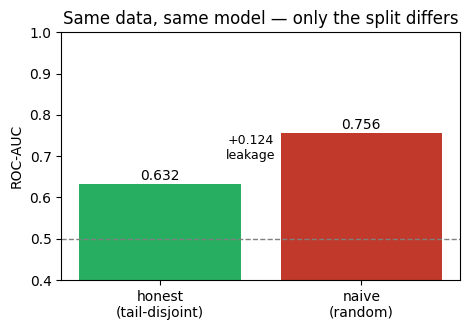

Reporting the naive number would overstate the system. GroupKFold is not optional.


In [13]:
plt.figure(figsize=(4.8,3.4))
bars = plt.bar(['honest\n(tail-disjoint)','naive\n(random)'], [honest, naive],
               color=['#27ae60','#c0392b'])
plt.axhline(0.5, ls='--', color='gray', lw=1); plt.ylim(0.4, 1.0)
plt.ylabel("ROC-AUC"); plt.title("Same data, same model — only the split differs")
for b,v in zip(bars,[honest,naive]): plt.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha='center')
plt.annotate(f"+{naive-honest:.3f}\nleakage", xy=(1,naive), xytext=(0.45,(honest+naive)/2),
             fontsize=9, ha='center')
plt.tight_layout(); plt.show()
print("Reporting the naive number would overstate the system. GroupKFold is not optional.")

## Part D — CLI parity: exactly what OpenClaw will drive

In Step 2 the agent does not import Python — it issues shell calls. Here we run all
four tools through the CLI and confirm the results match the in-process calls, so the
agent harness is exercising the same contract we just validated.

In [17]:
def cli(*args):
    cmd = [sys.executable, "-m", "scripts.tools", *args]
    # 2. Force the subprocess to run from the project root
    out = subprocess.run(cmd, capture_output=True, text=True, cwd=root)
    assert out.returncode == 0, f"Command failed:\n{out.stderr}"
    return json.loads(out.stdout)

# 3. Resolve all your relative paths to absolute paths so they survive the directory context switch
flight_dir_abs = Path(flight_dir).resolve()
meta_path_abs = Path(meta_path).resolve()
work_abs = Path(WORK).resolve()

# 4. Use the absolute paths in the CLI calls
ci = cli("inspect", "--flight-dir", str(flight_dir_abs), "--metadata", str(meta_path_abs))
cf = cli("featurize", "--flight-dir", str(flight_dir_abs), "--metadata", str(meta_path_abs), "--out", str(work_abs/"feats_cli.csv"))
cc = cli("classify", "--feats", str(work_abs/"feats_cli.csv"), "--model", str(work_abs/"model_easy.joblib"), "--out", str(work_abs/"preds_cli.json"))
cr = cli("recommend", "--preds", str(work_abs/"preds_cli.json"), "--queue", str(work_abs/"queue_cli.jsonl"), "--top-k", "10")

print("CLI inspect   :", {k:ci[k] for k in ('n_flights','n_channels','n_planes')})
print("CLI featurize :", {k:cf[k] for k in ('rows','n_features')})
print("CLI classify  :", {k:cc[k] for k in ('n_scored','n_high')})
print("CLI recommend :", {k:cr[k] for k in ('n_queued','queue')})

# (Assuming r_inspect and r_classify were defined in a cell above)
assert ci['n_flights'] == r_inspect['n_flights'] and cc['n_scored'] == r_classify['n_scored']
print("\nCLI parity OK — shell path matches in-process path. This is the surface OpenClaw calls.")

CLI inspect   : {'n_flights': 80, 'n_channels': 9, 'n_planes': 10}
CLI featurize : {'rows': 80, 'n_features': 109}
CLI classify  : {'n_scored': 80, 'n_high': 34}
CLI recommend : {'n_queued': 10, 'queue': '/home/ubuntupc/Documents/Github/agentic-ai-project/aviation_mas_mvp/nb_work/queue_cli.jsonl'}

CLI parity OK — shell path matches in-process path. This is the surface OpenClaw calls.


## What's validated, and what's next

**Validated here (Step 0).**
- The four-tool contract runs end-to-end; shapes and JSON line up.
- Tail-disjoint validation is wired, and we *measured* why it matters (honest vs leaked AUC).
- The HITL summary + approval gate are produced deterministically from tool outputs.
- CLI parity: the shell surface OpenClaw drives equals the validated in-process path.

**Next.**
- **Step 1 — real NGAFID-MC baseline (no LLM).** Download `hooong/ngafid-mc-20210917`,
  confirm the real column names, map them in `build_feature_table`, start with cluster
  **C28**, and record the *honest* GroupKFold AUC. Expect it **below** the paper's ~0.82 —
  that is the bridge-(1) ceiling, and it is fine.
- **Step 2 — single orchestrator in OpenClaw.** Wire the four CLI calls as tools, hand the
  agent `agent_task_brief.md`, run `qwen3-coder:30b` locally **non-headless first**. Diff its
  trace against the `orchestrator_sim` oracle above.
- **Step 5 — swap in Conv-MHSA.** Replace the body of `classify_flights` with a call to the
  trained model. Nothing else changes — same agents, same contract, paper-grade accuracy.

> Headline discipline: the deliverable validated at MVP is the **orchestration loop**, not the
> classifier. Report the honest baseline AUC as a baseline; let the Conv-MHSA swap carry accuracy.